In [1]:
import os
import random
from datetime import datetime

import pandas as pd
import polars as pl
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

import BinaryClassifier as BC
import HepG2Dataset as HG2D
import my_util

In [2]:
# Declare  variables, working directory and dataset directory
MODE = 'all_features'
NUM_EPOCHS = 100
START_EPOCH = 0
NUM_ITEMS = 35_450
BATCH_SIZE = 32
DROPOUT_RATE = 0.2

L1_lambda = 0.005
L2_lambda = 0.001
# L1_lambda = 0.0
# L2_lambda = 0.0

WORKING_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank'
DATASET_DIR = '/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/dataset'

MODEL_MODE = "dol1l2" # regular (reg), dropout (do), dropout + l1l2 (dol1l2)
PREFIX = f"{MODEL_MODE}-complex-{DROPOUT_RATE}"
SUFFIX = f"{NUM_ITEMS}-{NUM_EPOCHS}-{BATCH_SIZE}-{L1_lambda}-{L2_lambda}"

CHECKPOINT_NAME = os.path.join(WORKING_DIR, 'output', 'model', MODE, "deepchrome-alike", f'{PREFIX}-checkpoint-{SUFFIX}.pt')

IMAGE_FILE = os.path.join(WORKING_DIR, 'output', 'img', 'train', MODE, "deepchrome-alike", f"{PREFIX}-ranking-{SUFFIX}.png")
TEST_FILE = os.path.join(WORKING_DIR, 'output', 'test', MODE, "deepchrome-alike", f"{PREFIX}-test-results-{SUFFIX}.txt")
TRAINING_FILE = os.path.join(WORKING_DIR, 'output', 'train', MODE, "deepchrome-alike", f"{PREFIX}-train-validation-metrics-{SUFFIX}.csv")
TEST_RESULT_FILE = os.path.join(WORKING_DIR, 'output', 'test', MODE, "deepchrome-alike", f"{PREFIX}-test-metrics-{SUFFIX}.csv")
ROC_FILE = os.path.join(WORKING_DIR, 'output', 'img', 'roc', MODE, "deepchrome-alike", f"{PREFIX}-roc-{SUFFIX}.png")
CM_FILE = os.path.join(WORKING_DIR, 'output', 'img', 'confusion_matrix', MODE, "deepchrome-alike", f"{PREFIX}-cm-{SUFFIX}.png")

INPUT_SIZE = 40_000

print(CHECKPOINT_NAME)

/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/output/model/all_features/deepchrome-alike/dol1l2-complex-0.2-checkpoint-35450-100-32-0.005-0.001.pt


In [3]:
device = my_util.get_device()

Using device: cuda
Current CUDA device: 0
CUDA device name: Tesla P100-SXM2-16GB


In [4]:
# Load dataset
all_features = pl.read_parquet(os.path.join(DATASET_DIR, 'features', f'{MODE}.parquet'))
all_features

index,gene_id,all_features,value_1
u32,str,list[f64],f64
0,"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0
1,"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0
2,"""XLOC_000006""","[0.0, 0.0, … 0.0]",0.0888452
3,"""XLOC_000007""","[0.0, 0.0, … 0.0]",4.04743
4,"""XLOC_000008""","[0.0, 0.0, … 0.0]",26.7934
…,…,…,…
22149,"""XLOC_030009""","[0.0, 0.0, … 0.0]",0.0
22150,"""XLOC_030012""","[0.0, 0.0, … 0.0]",0.0
22151,"""XLOC_030014""","[0.0, 0.0, … 0.0]",0.0


In [5]:
# Find the gene with median value
median_value = all_features["value_1"].median()
median_value

1.1420949999999999

In [6]:
result = all_features.select(
    pl.all(),
    (pl.col("value_1") - median_value).abs().alias("diff")
)

result

index,gene_id,all_features,value_1,diff
u32,str,list[f64],f64,f64
0,"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,1.142095
1,"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0,1.142095
2,"""XLOC_000006""","[0.0, 0.0, … 0.0]",0.0888452,1.0532498
3,"""XLOC_000007""","[0.0, 0.0, … 0.0]",4.04743,2.905335
4,"""XLOC_000008""","[0.0, 0.0, … 0.0]",26.7934,25.651305
…,…,…,…,…
22149,"""XLOC_030009""","[0.0, 0.0, … 0.0]",0.0,1.142095
22150,"""XLOC_030012""","[0.0, 0.0, … 0.0]",0.0,1.142095
22151,"""XLOC_030014""","[0.0, 0.0, … 0.0]",0.0,1.142095


In [7]:
min_diff = result["diff"].min()
min_diff

0.00019499999999994522

In [8]:
median_gene = result.filter(pl.col("diff") == min_diff).drop("diff")
median_gene

index,gene_id,all_features,value_1
u32,str,list[f64],f64
18742,"""XLOC_025348""","[0.0, 0.0, … 0.0]",1.1419


In [9]:
# Select the dataframe without the median gene
all_genes = result.filter(pl.col("gene_id") != 'XLOC_025348')
all_genes

index,gene_id,all_features,value_1,diff
u32,str,list[f64],f64,f64
0,"""XLOC_000001""","[0.0, 0.0, … 0.0]",0.0,1.142095
1,"""XLOC_000003""","[0.0, 0.0, … 0.0]",0.0,1.142095
2,"""XLOC_000006""","[0.0, 0.0, … 0.0]",0.0888452,1.0532498
3,"""XLOC_000007""","[0.0, 0.0, … 0.0]",4.04743,2.905335
4,"""XLOC_000008""","[0.0, 0.0, … 0.0]",26.7934,25.651305
…,…,…,…,…
22149,"""XLOC_030009""","[0.0, 0.0, … 0.0]",0.0,1.142095
22150,"""XLOC_030012""","[0.0, 0.0, … 0.0]",0.0,1.142095
22151,"""XLOC_030014""","[0.0, 0.0, … 0.0]",0.0,1.142095


In [10]:
median_gene_np = median_gene.to_numpy()
median_gene_np

array([[18742, 'XLOC_025348', array([0., 0., 0., ..., 0., 0., 0.]),
        1.1419]], dtype=object)

In [11]:
median_gene_np[0, 2]

array([0., 0., 0., ..., 0., 0., 0.])

In [12]:
# Convert to numpy array
all_genes_np = all_genes.to_numpy()

In [13]:
# Split train, test, validation by index
data_indices = np.arange(len(all_genes_np))
print(data_indices)

[    0     1     2 ... 22150 22151 22152]


In [14]:
# First split: 80% train, 20% temporary (for test + validation)
train_idx, temp_idx = train_test_split(
    data_indices, 
    test_size=0.2, 
    random_state=42  # For reproducibility
)

In [15]:
# Second split: Split temp_idx into 50% test and 50% validation
val_idx, test_idx = train_test_split(
    temp_idx, 
    test_size=0.5, 
    random_state=42  # Same random_state for consistency
)

In [16]:
print(train_idx)
print(val_idx)
print(test_idx)

[12829 12333  8225 ...  5390   860 15795]
[13202 15153  3113 ...  1158  6603 15289]
[21274  8344  1396 ...  7985   482 16492]


In [17]:
# Result: train_idx (80%), test_idx (10%), val_idx (10%)
print(f"Train indices: {len(train_idx)}")
print(f"Test indices: {len(test_idx)}")
print(f"Validation indices: {len(val_idx)}")

Train indices: 17722
Test indices: 2216
Validation indices: 2215


In [18]:
# Define the dataset
train_dataset = HG2D.HepG2DatasetMedian(int(0.8 * NUM_ITEMS), all_genes_np, train_idx, median_gene_np)
val_dataset = HG2D.HepG2DatasetMedian(int(0.1 * NUM_ITEMS), all_genes_np, val_idx, median_gene_np)
test_dataset = HG2D.HepG2DatasetMedian(int(0.1 * NUM_ITEMS), all_genes_np, test_idx, median_gene_np)

In [19]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

28360
3545
3545


In [20]:
# Define the dataloader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

In [21]:
# Initialize model
# model = BC.BinaryClassifierDropOutL1L2(input_size=INPUT_SIZE, dropout_rate=DROPOUT_RATE, l1_lambda=L1_lambda, l2_lambda=L2_lambda).to(device)

hidden_sizes = [1024, 512, 256]
# model = BC.BinaryClassifierDropOutL1L2(input_size=INPUT_SIZE, dropout_rate=DROPOUT_RATE, l1_lambda=L1_lambda, l2_lambda=L2_lambda).to(device)
model = BC.FlexibleBinaryClassifierDropOutL1L2(input_size=INPUT_SIZE, 
                                               hidden_sizes=hidden_sizes, 
                                               dropout_rate=DROPOUT_RATE, 
                                               l1_lambda=L1_lambda, 
                                               l2_lambda=L2_lambda).to(device)

# Define loss function for binary classification
criterion = nn.BCELoss()  # Binary Cross Entropy Loss

# Training loop example
optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)

# Define learning rate scheduler
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.1)

In [22]:
print(model)

FlexibleBinaryClassifierDropOutL1L2(
  (network): Sequential(
    (0): Linear(in_features=40000, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.1)
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


In [23]:
# Arrays for saving the performance metric
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []
val_precisions = []
val_recalls = []
val_f1_scores = []

In [24]:
# Check if the checkpoint exists
if os.path.exists(CHECKPOINT_NAME):
    checkpoint = torch.load(CHECKPOINT_NAME)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler'])
    START_EPOCH = checkpoint['epoch'] + 1
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    train_accuracies = checkpoint['train_accuracies']
    val_accuracies = checkpoint['val_accuracies']
    train_aucs = checkpoint['train_aucs']
    val_aucs = checkpoint['val_aucs']
    val_precisions = checkpoint['val_precisions']
    val_recalls = checkpoint['val_recalls']
    val_f1_scores = checkpoint['val_f1_scores']

    print(f"{CHECKPOINT_NAME} exists. Resuming training from epoch {START_EPOCH}.")
else:
    print("No checkpoint found.")
    START_EPOCH = 0

/group/pmc021/amunif/epi-thesis/workflow/09_Learning_to_Rank/output/model/all_features/deepchrome-alike/dol1l2-complex-0.2-checkpoint-35450-100-32-0.005-0.001.pt exists. Resuming training from epoch 100.


In [25]:
# Training loop
for epoch in range(START_EPOCH, NUM_EPOCHS):
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0
    train_true_labels = []
    train_predicted_labels = []

    # Training phase
    for X_batch, y_batch in train_loader:

        if (MODEL_MODE == "reg") or (MODEL_MODE == "do"):
            outputs = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device))
        elif MODEL_MODE == "dol1l2":
            outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
            loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        predictions = (outputs.squeeze(1) >= 0.5).long()

        train_loss += loss.item()
        train_correct += (predictions == y_batch.to(device)).sum().item()
        train_total += y_batch.size(0)
        
        train_true_labels.extend(y_batch.cpu().numpy())
        train_predicted_labels.extend(predictions.cpu().numpy())
        
    # # Adjust learning rate
    # scheduler.step()
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total
    train_auc_score = roc_auc_score(train_true_labels, train_predicted_labels)

    train_losses.append(round(avg_train_loss, 4))
    train_accuracies.append(round(train_accuracy, 2))
    train_aucs.append(round(train_auc_score, 2))

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_metric = 0
    val_true_labels = []
    val_predicted_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            
            if (MODEL_MODE == "reg") or (MODEL_MODE == "do"):
                outputs = model(X_batch.to(dtype=torch.float32).to(device))
                loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device))
            elif MODEL_MODE == "dol1l2":
                outputs, l1_reg, l2_reg = model(X_batch.to(dtype=torch.float32).to(device))
                loss = criterion(outputs.squeeze(1), y_batch.to(dtype=torch.float32).to(device)) + l1_reg + l2_reg
            
            predictions = (outputs.squeeze(1) >= 0.5).long()
            
            val_loss += loss.item()
            val_correct += (predictions == y_batch.to(dtype=torch.float32).to(device)).sum().item()
            val_total += y_batch.size(0)
            val_true_labels.extend(y_batch.cpu().numpy())
            val_predicted_labels.extend(predictions.cpu().numpy())
            
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total
        val_metric = val_correct / len(val_loader)

        # Calculate precision, recall, and F1-score
        precision, recall, f1_score, _ = precision_recall_fscore_support(
            val_true_labels, 
            val_predicted_labels, 
            average='binary'  # Use macro average for multi-class classification
        )

        val_true_labels = np.array(val_true_labels)
        val_predicted_labels = np.array(val_predicted_labels)
        val_auc_score = roc_auc_score(val_true_labels, val_predicted_labels)

        val_losses.append(round(avg_val_loss, 4))
        val_accuracies.append(round(val_accuracy, 2))
        val_aucs.append(round(val_auc_score, 2))
        val_precisions.append(round(precision, 2))
        val_recalls.append(round(recall, 2))
        val_f1_scores.append(round(f1_score, 2))

    # Adjust learning rate
    scheduler.step(val_loss)

    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] - '
          f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, AUC: {train_auc_score:.2f} '
          f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, '
          f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1_score:.2f}, '
          f'AUC: {val_auc_score:.2f}')
    
    # Save the model
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'train_aucs': train_aucs,
        'val_aucs': val_aucs,
        'val_precisions': val_precisions,
        'val_recalls': val_recalls,
        'val_f1_scores': val_f1_scores,
    }, CHECKPOINT_NAME)

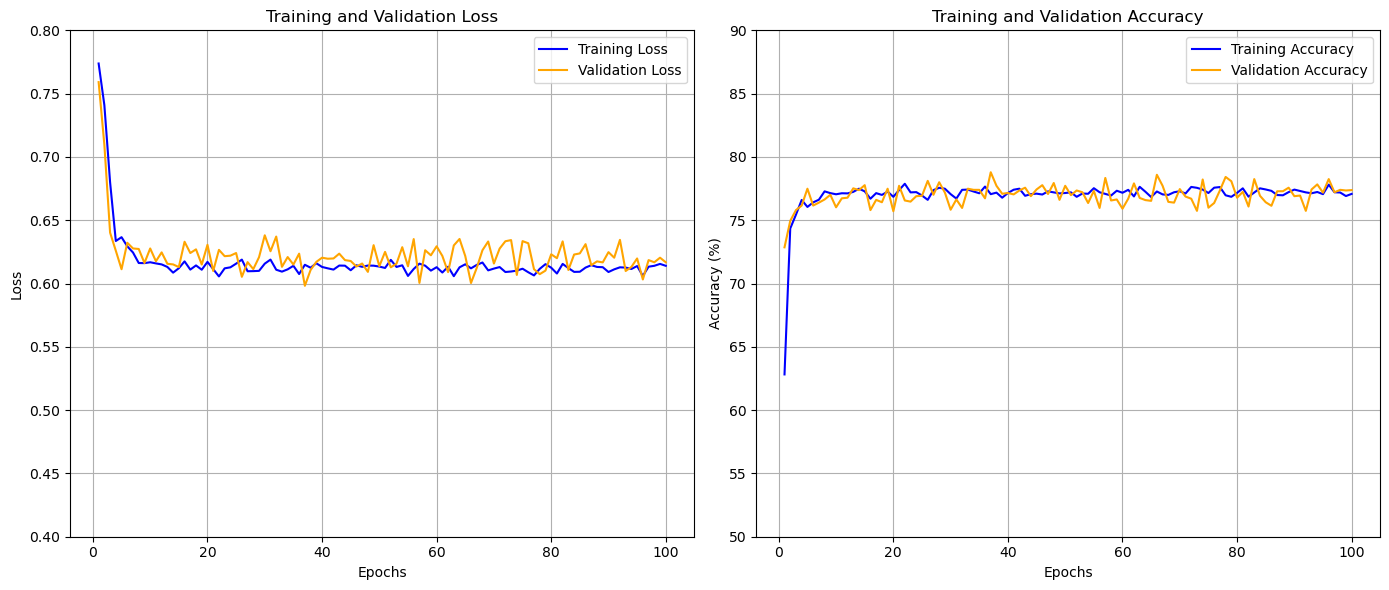

In [26]:
# Plot metrics
my_util.plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, NUM_ITEMS, IMAGE_FILE)

In [27]:
# Predict on test set
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        if (MODEL_MODE == "reg") or (MODEL_MODE == "do"):
            outputs = model(X_batch.to(dtype=torch.float32).to(device))
        elif MODEL_MODE == "dol1l2":
            outputs, _, _ = model(X_batch.to(dtype=torch.float32).to(device))
        
        predictions = (outputs.squeeze(1) >= 0.5).long()
        test_true_labels.extend(y_batch.cpu().numpy())
        test_predictions.extend(predictions.cpu().numpy())

In [28]:
# Evaluation metrics
# Precision, Recall, F1-Score
precision, recall, f1_score, _ = precision_recall_fscore_support(
    test_true_labels, 
    test_predictions, 
    average='binary'  # Use 'macro' for multi-class
)

test_acc_score = accuracy_score(test_true_labels, test_predictions) * 100
test_auc_score = roc_auc_score(test_true_labels, test_predictions)
cr = classification_report(test_true_labels, test_predictions)
cm = confusion_matrix(test_true_labels, test_predictions)

In [29]:
test_output = f"""Accuracy Score on test set: {test_acc_score:.2f} %
AUC Score on test set: {test_auc_score:.2f}
Precision: {precision:.4f}
Recall: {recall:.4f}
F1-Score: {f1_score:.4f}

Detailed Classification Report:
{cr}

Confusion Matrix:
{cm}
"""

print(test_output)

Accuracy Score on test set: 75.18 %
AUC Score on test set: 0.75
Precision: 0.7537
Recall: 0.7443
F1-Score: 0.7490

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.76      0.75      1781
           1       0.75      0.74      0.75      1764

    accuracy                           0.75      3545
   macro avg       0.75      0.75      0.75      3545
weighted avg       0.75      0.75      0.75      3545


Confusion Matrix:
[[1352  429]
 [ 451 1313]]



In [30]:
# Save the test output to text file
with open(TEST_FILE, 'w', newline = '') as text_file:
    text_file.write(test_output)

In [31]:
# Training metrics
experiment_results = {
    'train_loss'    : train_losses,
    'train_accuracy': train_accuracies,
    'train_auc'     : train_aucs,
    'val_loss'      : val_losses,
    'val_accuracy'  : val_accuracies,
    'val_auc'       : val_aucs
}

experiment_pl = pl.DataFrame(experiment_results)
experiment_pl.write_csv(TRAINING_FILE)

In [32]:
# Test output
test_results = {
    'test_acc'    : round(test_acc_score, 4),
    'test_auc'    : round(test_auc_score, 4)
}

test_pl = pl.DataFrame(test_results)
test_pl.write_csv(TEST_RESULT_FILE)

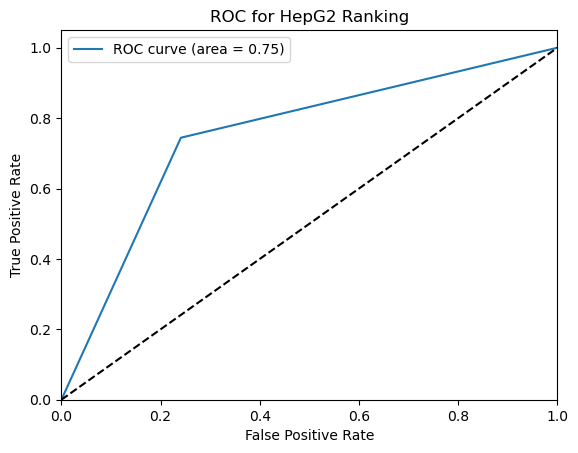

In [33]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_true_labels, test_predictions) 
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()  
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC for HepG2 Ranking')
plt.legend()

plt.savefig(ROC_FILE)

plt.show()

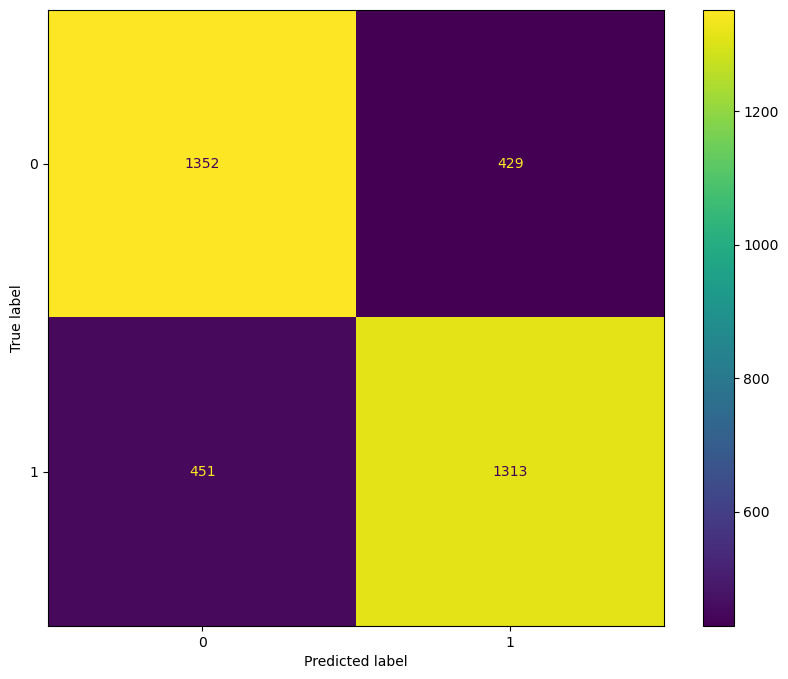

In [34]:
# Plot the confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(10, 8))
cm_display.plot(ax=ax)
plt.savefig(CM_FILE)